In [23]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
df = pd.read_csv("files/penguins.csv")
df.head()

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [25]:
df.shape


(344, 9)

In [26]:
df.columns

Index(['Unnamed: 0', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [28]:
df.isnull().sum()

Unnamed: 0            0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [29]:
numeric_df=df.select_dtypes(include=["int64","float64"])
numeric_cols=numeric_df.columns
print(numeric_cols)

Index(['Unnamed: 0', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'year'],
      dtype='object')


In [30]:
string_df=df.select_dtypes(include="object")
string_cols=string_df.columns
print(string_cols)

Index(['species', 'island', 'sex'], dtype='object')


In [31]:
df[numeric_cols]=df[numeric_cols].fillna(numeric_df.median())
df[string_cols]=df[string_cols].fillna("Unknown")

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     344 non-null    float64
 4   bill_depth_mm      344 non-null    float64
 5   flipper_length_mm  344 non-null    float64
 6   body_mass_g        344 non-null    float64
 7   sex                344 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [33]:
corr_matrix=numeric_df.corr()
print(corr_matrix)

                   Unnamed: 0  bill_length_mm  bill_depth_mm  \
Unnamed: 0           1.000000        0.766039      -0.259563   
bill_length_mm       0.766039        1.000000      -0.235053   
bill_depth_mm       -0.259563       -0.235053       1.000000   
flipper_length_mm    0.455372        0.656181      -0.583851   
body_mass_g          0.275493        0.595110      -0.471916   
year                 0.339103        0.054545      -0.060354   

                   flipper_length_mm  body_mass_g      year  
Unnamed: 0                  0.455372     0.275493  0.339103  
bill_length_mm              0.656181     0.595110  0.054545  
bill_depth_mm              -0.583851    -0.471916 -0.060354  
flipper_length_mm           1.000000     0.871202  0.169675  
body_mass_g                 0.871202     1.000000  0.042209  
year                        0.169675     0.042209  1.000000  


In [ ]:
exclude_feature=['Unnamed']

<Axes: >

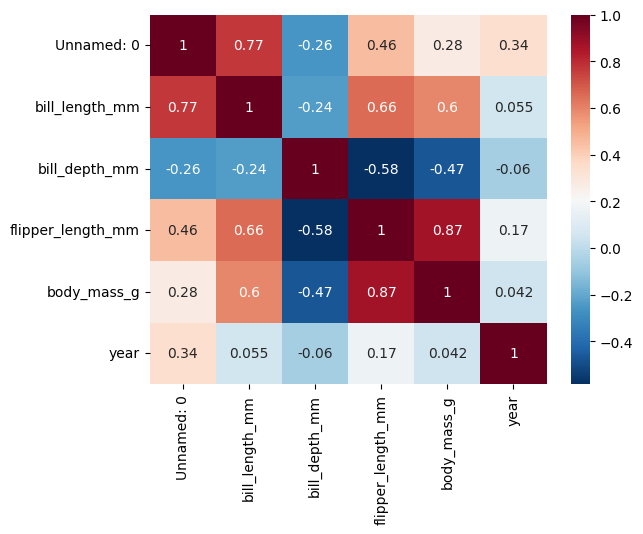

In [37]:
sns.heatmap(corr_matrix,annot=True,cmap="RdBu_r")